#### Case 1: Isobaric evaporation of liquid hydrogen in a 18.09 $m^3$ Cylindrical tank experiment MHTB.

This notebook sets up the isobaric evaporation of liquid hydrogen ($LH_2$) 

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Read data from excel
import pandas as pd

import os

### Carga de datos experimentales desde excel

In [2]:
excel_path = "../data/Data_Wang_Merida.xlsx"

if not os.path.exists(excel_path):
    raise FileNotFoundError(f"No se encontró el archivo en: {excel_path}. Verifica la carpeta.")

# Vertical Cylinder Tank
df_mhtb_p = pd.read_excel(excel_path, sheet_name="MHTB_P")
df_mhtb_tv = pd.read_excel(excel_path, sheet_name="MHTB_Tv")

# Limpiar las curvas de temperatura para eliminar filas sin datos (NaNs)
exp_tv_95 = df_mhtb_tv[['Time_95 (min)', 'Temp_95 (K)']].dropna()
exp_tv_98 = df_mhtb_tv[['Time_98 (min)', 'Temp_98 (K)']].dropna()

# Spherical Tank 
df_ksite_p = pd.read_excel(excel_path, sheet_name="KSite_P")
df_ksite_tl = pd.read_excel(excel_path, sheet_name="KSite_Tl")
df_ksite_tv = pd.read_excel(excel_path, sheet_name="KSite_Tv")


In [4]:
# Propiedades geométricas y de operación de la NASA
d_i_m = 3.05       # Diámetro interno del tanque (m)
d_o_m = 3.25       # Diámetro externo del tanque (m)
V_tank_m = 18.09   # Volumen total del tanque (m3)
LF_m = 0.90        # Nivel de llenado inicial (90% de líquido)
P_init_m = 113000  # Presión de operación inicial (113,000 Pa o 113 kPa)

# Propiedades térmicas globales de la pared
U_L_m = 5.187e-3   # Coeficiente global de transferencia (líquido) (W/m2/K)
U_V_m = 5.187e-3   # Coeficiente global de transferencia (vapor) (W/m2/K)
T_air = 293.15     # Temperatura ambiente externa (K)
eta_w_m = 0.876    # Fracción de calor de la pared que va directo a la interfaz

# Inicializar el hidrógeno criogénico y cargar CoolProp
hydrogen_m = Cryogen(name="hydrogen")
hydrogen_m.set_coolprops(P_init_m)

# Construir el objeto Tanque Vertical
tank_mhtb = Tank(d_i_m, d_o_m, V_tank_m, 'cylindrical', 'cylindrical', LF_m)

# Aplicamos las propiedades de pared (techo y fondo aislados para MHTB)
tank_mhtb.set_HeatTransProps(U_L_m, U_V_m, T_air, eta_w=eta_w_m)
tank_mhtb.cryogen = hydrogen_m

# Discretización
dz = 0.01          # Espaciamiento vertical de la grilla (1 cm)
# Calculamos el número de nodos dividiendo la altura del vapor por dz
n_z_m = 1 + int(np.round(tank_mhtb.l_V/dz, 0))
# Generamos un vector de 0 a 1 con la cantidad de nodos necesaria
tank_mhtb.z_grid = np.linspace(0, 1, n_z_m)
tank_mhtb.time_interval = 60  # Guardar datos simulados cada 60 segundos

# Correr la simulación
evap_time_m = 320 * 60  # 320 minutos convertidos a segundos 
tank_mhtb.evaporate(evap_time_m)

In [ ]:
""""
# Propiedades geométricas y de operación del K-site
d_i_k = 2.106     # Diámetro equivalente para una esfera perfecta (m)
d_o_k = 2.306     # Diámetro externo (m)
V_tank_k = 4.89   # Volumen total del tanque (m3)
LF_k = 0.49       # Nivel de llenado inicial (49% de líquido)
P_init_k = 103700 # Presión inicial (103.7 kPa)

# Propiedades térmicas globales de la pared
# La NASA reportó un ingreso de calor de 3.5 W/m2.
# U = 3.5 / (293.15 - 24.4) = 0.01302 W/(m2*K)
U_L_k = 0.01302   
U_V_k = 0.01302   
T_air = 293.15    # Temperatura ambiente externa (K)
eta_w_k = 0.85    # Partición de calor inicial para ajuste esférico

# Inicializar el hidrógeno criogénico
hydrogen_k = Cryogen(name="hydrogen")
hydrogen_k.set_coolprops(P_init_k)

# Construir el objeto Tanque Esférico
tank_ksite = Tank(d_i_k, d_o_k,V_tank_k, 'spherical','spherical', LF_k)

# Aplicamos las propiedades de pared 
tank_ksite.set_HeatTransProps(U_L_k, U_V_k, T_air, Q_b_fixed=0, eta_w=eta_w_k)
tank_ksite.cryogen = hydrogen_k
 # Esto lo forcé por que no aceptaba Q_b = 0 en set_HeatTransProps

# Definir la grilla matemática (Discretización)
dz = 0.01          # Espaciamiento vertical de la grilla (1 cm)
n_z_k = 1 + int(np.round(tank_ksite.l_V/dz, 0))
tank_ksite.z_grid = np.linspace(0, 1, n_z_k)
tank_ksite.time_interval = 60  # Guardar datos simulados cada 60 segundos

# Correr la simulación dinámica
evap_time_k = 1200 * 60  # 1200 minutos convertidos a segundos (72,000 s)
tank_ksite.evaporate(evap_time_k)

"""

c:\Users\fabia\IPRE\CryoEvap\notebooks\..\cryoevap\storage_tanks\tank.py:550: RuntimeWarning: divide by zero encountered in divide
  vz = self.v_z*(l_L[i]/zed)*(2*self.d_i/2 - l_L[i])/(2*self.d_i/2 - zed) #PReguntar a profesor por esto


### Gráficas 

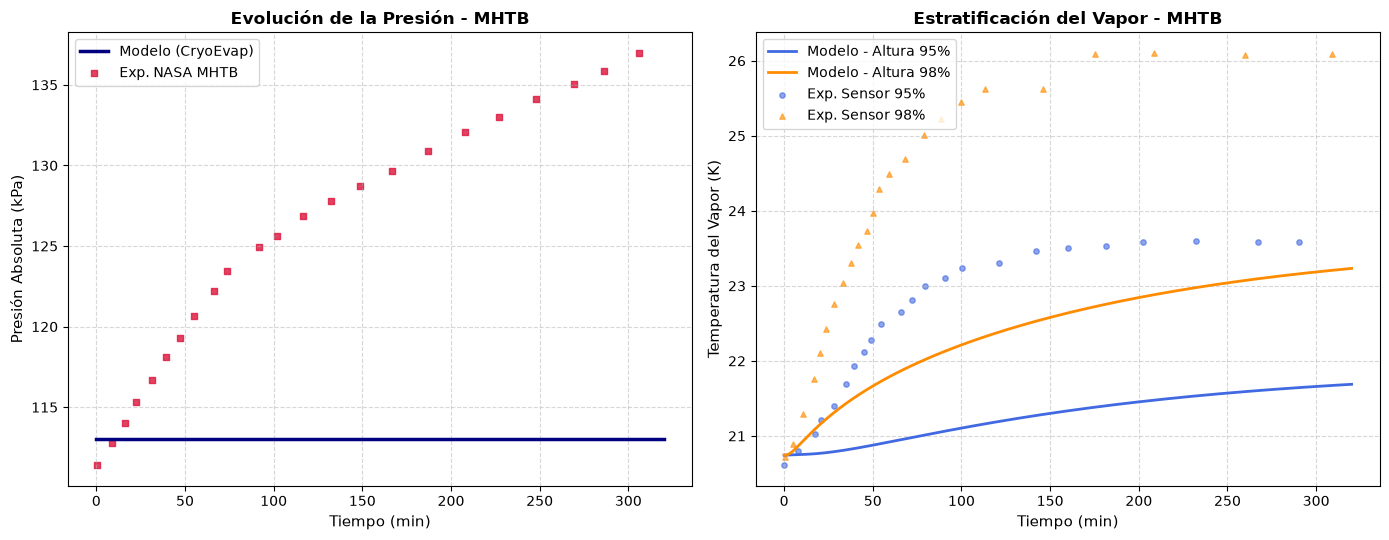

In [14]:
fig1, (ax1_p, ax1_t) = plt.subplots(1, 2, figsize=(14, 5.5))

# Presión MHTB (Como es isobárico, se mantiene constante en P_init_m)
time_mhtb_min = tank_mhtb.sol.t / 60
pres_mhtb_kpa = np.ones_like(time_mhtb_min) * (P_init_m / 1000) # Creará una línea recta en 113 kPa

ax1_p.plot(time_mhtb_min, pres_mhtb_kpa, color='navy', linewidth=2.5, label='Modelo (CryoEvap)')
ax1_p.scatter(df_mhtb_p['Time (min)'], df_mhtb_p['Pressure (kPa)'], 
             color='crimson', marker='s', s=20, alpha=0.8, label='Exp. NASA MHTB')
ax1_p.set_title("Evolución de la Presión - MHTB", fontsize=12, fontweight='bold')
ax1_p.set_xlabel("Tiempo (min)", fontsize=11)
ax1_p.set_ylabel("Presión Absoluta (kPa)", fontsize=11)
ax1_p.grid(True, linestyle='--', alpha=0.5)
ax1_p.legend(fontsize=10)

# Temperatura de Vapor MHTB 
# MHTB está al 90% de llenado inicial (LF = 0.90)
# Sensor 95% total -> z = (0.95 - 0.90) / (1.0 - 0.90) = 0.50 de la zona de vapor
# Sensor 98% total -> z = (0.98 - 0.90) / (1.0 - 0.90) = 0.80 de la zona de vapor
idx_95 = np.abs(tank_mhtb.z_grid - 0.50).argmin()
idx_98 = np.abs(tank_mhtb.z_grid - 0.80).argmin()

# Las temperaturas de vapor están en y[2:]
temp_95_sim = tank_mhtb.sol.y[2 + idx_95]
temp_98_sim = tank_mhtb.sol.y[2 + idx_98]

ax1_t.plot(time_mhtb_min, temp_95_sim, color='royalblue', linewidth=2, label='Modelo - Altura 95%')
ax1_t.plot(time_mhtb_min, temp_98_sim, color='darkorange', linewidth=2, label='Modelo - Altura 98%')
ax1_t.scatter(exp_tv_95['Time_95 (min)'], exp_tv_95['Temp_95 (K)'], 
             color='royalblue', marker='o', s=15, alpha=0.6, label='Exp. Sensor 95%')
ax1_t.scatter(exp_tv_98['Time_98 (min)'], exp_tv_98['Temp_98 (K)'], 
             color='darkorange', marker='^', s=15, alpha=0.6, label='Exp. Sensor 98%')

ax1_t.set_title("Estratificación del Vapor - MHTB", fontsize=12, fontweight='bold')
ax1_t.set_xlabel("Tiempo (min)", fontsize=11)
ax1_t.set_ylabel("Temperatura del Vapor (K)", fontsize=11)
ax1_t.grid(True, linestyle='--', alpha=0.5)
ax1_t.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
#Falta revisar bien el esferico y ver para los casos BOG usando el modelo de no equilibrio de Wang y Merida.